In [1]:
import time
import category_encoders as ce
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Wczytanie danych
dataset = pd.read_csv(
    r'C:\Users\Alicja\Desktop\kurs-datascience\DataCoSupplyChainDataset.csv',
    encoding='latin1',
)

# Tłumaczenie kolumn
tłumaczenie_kolumn = {
    'Type': 'Typ_platnosci',
    'Days for shipping (real)': 'Rzeczywiste_dni_wysylki',
    'Days for shipment (scheduled)': 'Planowane_dni_wysylki',
    'Benefit per order': 'Zysk_na_zamowienie',
    'Sales per customer': 'Sprzedaz_na_klienta',
    'Delivery Status': 'Status_dostawy',
    'Late_delivery_risk': 'Ryzyko_opoznienia',
    'Category Name': 'Nazwa_kategorii',
    'Customer City': 'Miasto_klienta',
    'Customer Country': 'Kraj_klienta',
    'Customer State': 'Stan_klienta',
    'Department Name': 'Nazwa_dzialu',
    'Market': 'Rynek',
    'Order City': 'Miasto_zamowienia',
    'Order Country': 'Kraj_zamowienia',
    'order date (DateOrders)': 'Data_zamowienia',
    'Order Item Discount': 'Rabat_pozycji',
    'Order Item Discount Rate': 'Stopa_rabatu_pozycji',
    'Order Item Product Price': 'Cena_produktu_w_zamowieniu',
    'Order Item Profit Ratio': 'Wspolczynnik_zysku_pozycji',
    'Order Item Quantity': 'Ilosc_pozycji',
    'Sales': 'Sprzedaz_brutto',
    'Order Item Total': 'Suma_pozycji_netto',
    'Order Status': 'Status_zamowienia',
    'Product Name': 'Nazwa_produktu',
    'Product Price': 'Cena_produktu',
    'Shipping date (DateOrders)': 'Data_wysylki',
    'Shipping Mode': 'Tryb_wysylki',
}
dataset.rename(columns=tłumaczenie_kolumn, inplace=True)

# Tworzenie cech czasowych
dataset['Data_zamowienia'] = pd.to_datetime(
    dataset['Data_zamowienia'], format='%m/%d/%Y %H:%M'
)
dataset['Dzien_tygodnia_zamowienia'] = dataset['Data_zamowienia'].dt.dayofweek
dataset['Miesiac_zamowienia'] = dataset['Data_zamowienia'].dt.month

# Podział na typy cech
cechy_numeryczne = [
    'Planowane_dni_wysylki',
    'Cena_produktu',
    'Ilosc_pozycji',
    'Rabat_pozycji',
    'Stopa_rabatu_pozycji',
    'Dzien_tygodnia_zamowienia',
    'Miesiac_zamowienia',
]
cechy_onehot = ['Tryb_wysylki', 'Rynek', 'Typ_platnosci', 'Nazwa_dzialu']
cechy_target_encoding = [
    'Miasto_klienta',
    'Kraj_klienta',
    'Stan_klienta',
    'Miasto_zamowienia',
    'Kraj_zamowienia',
    'Nazwa_kategorii',
    'Nazwa_produktu',
]

X = dataset[cechy_numeryczne + cechy_onehot + cechy_target_encoding]
y = dataset['Ryzyko_opoznienia']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kodowanie zmiennych kategorialnych
# One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=cechy_onehot)
X_test = pd.get_dummies(X_test, columns=cechy_onehot)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Target Encoding z wygładzaniem (smoothing)
encoder = ce.TargetEncoder(cols=cechy_target_encoding, smoothing=10)
X_train[cechy_target_encoding] = encoder.fit_transform(
    X_train[cechy_target_encoding], y_train
)
X_test[cechy_target_encoding] = encoder.transform(
    X_test[cechy_target_encoding]
)

# Skalowanie cech dla modeli wrażliwych na skalę (np. Regresja Logistyczna)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing gotowy:", X_train.shape, X_test.shape)

# Definicja i uczenie modeli
modele = {
    'Baseline (Dummy)': DummyClassifier(
        strategy='most_frequent', random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

wyniki = {}
for nazwa, model in modele.items():
    start = time.time()

    # Wybór odpowiednio przygotowanych danych zależnie od typu modelu
    if nazwa == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    czas = time.time() - start
    acc = accuracy_score(y_test, y_pred)
    wyniki[nazwa] = {'accuracy': acc, 'czas_s': czas, 'model': model}

    print(f'\n {nazwa} ')
    print(f'Accuracy: {acc:.4f} | Czas: {czas:.2f}s')
    print(classification_report(y_test, y_pred, zero_division=0))

# Podsumowanie wyników
print('\nPODSUMOWANIE\n' )
for nazwa, dane in wyniki.items():
    print(
        f"{nazwa:<20}: accuracy = {dane['accuracy']:.4f} | czas = {dane['czas_s']:.2f}s"
    )

Preprocessing gotowy: (144415, 38) (36104, 38)

 Baseline (Dummy) 
Accuracy: 0.5483 | Czas: 0.01s
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     16308
           1       0.55      1.00      0.71     19796

    accuracy                           0.55     36104
   macro avg       0.27      0.50      0.35     36104
weighted avg       0.30      0.55      0.39     36104


 Logistic Regression 
Accuracy: 0.7027 | Czas: 0.51s
              precision    recall  f1-score   support

           0       0.64      0.76      0.70     16308
           1       0.77      0.65      0.71     19796

    accuracy                           0.70     36104
   macro avg       0.71      0.71      0.70     36104
weighted avg       0.71      0.70      0.70     36104


 Random Forest 
Accuracy: 0.7799 | Czas: 53.42s
              precision    recall  f1-score   support

           0       0.73      0.81      0.77     16308
           1       0.83      0.75   

cross-validation na Random Forest

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_do_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start = time.time()
scores_rf = cross_val_score(rf_do_cv, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
czas_cv = time.time() - start

print("Cross-validation: Random Forest")
print(f"Wyniki z 5 foldów: {np.round(scores_rf, 4)}")
print(f"Średnia: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")
print(f"Czas: {czas_cv:.2f}s")

Cross-validation: Random Forest
Wyniki z 5 foldów: [0.7759 0.7719 0.7726 0.7747 0.7778]
Średnia: 0.7746 ± 0.0021
Czas: 287.61s


In [3]:
from scipy import stats

# Cross-validation na Logistic Regression (do porównania z Random Forest)
log_reg_do_cv = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
scores_lr = cross_val_score(log_reg_do_cv, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
czas_cv_lr = time.time() - start

print("Cross-validation: Logistic Regression")
print(f"Wyniki z 5 foldów: {np.round(scores_lr, 4)}")
print(f"Średnia: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")
print(f"Czas: {czas_cv_lr:.2f}s")

Cross-validation: Logistic Regression
Wyniki z 5 foldów: [0.7173 0.714  0.7153 0.7154 0.7143]
Średnia: 0.7153 ± 0.0012
Czas: 116.65s


In [4]:

t_stat, p_value = stats.ttest_rel(scores_rf, scores_lr)

print("\nTest istotności statystycznej (paired t-test)")
print(f"Random Forest - średnia: {scores_rf.mean():.4f}")
print(f"Logistic Regression - średnia: {scores_lr.mean():.4f}")
print(f"Różnica: {scores_rf.mean() - scores_lr.mean():.4f}")
print(f"t-statystyka: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n Różnica jest statystycznie istotna (p < 0.05)")
else:
    print("\n Różnica NIE jest statystycznie istotna (p >= 0.05)")


Test istotności statystycznej (paired t-test)
Random Forest - średnia: 0.7746
Logistic Regression - średnia: 0.7153
Różnica: 0.0593
t-statystyka: 53.5893
p-value: 0.000001

 Różnica jest statystycznie istotna (p < 0.05)


In [5]:
import shap

rf_model = wyniki["Random Forest"]["model"]


explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")

# ilość próbek: 100
X_sample = X_test.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample, check_additivity=False)

print("Typ:", type(shap_values))
print("Kształt:", np.array(shap_values).shape)

Typ: <class 'numpy.ndarray'>
Kształt: (100, 38, 2)


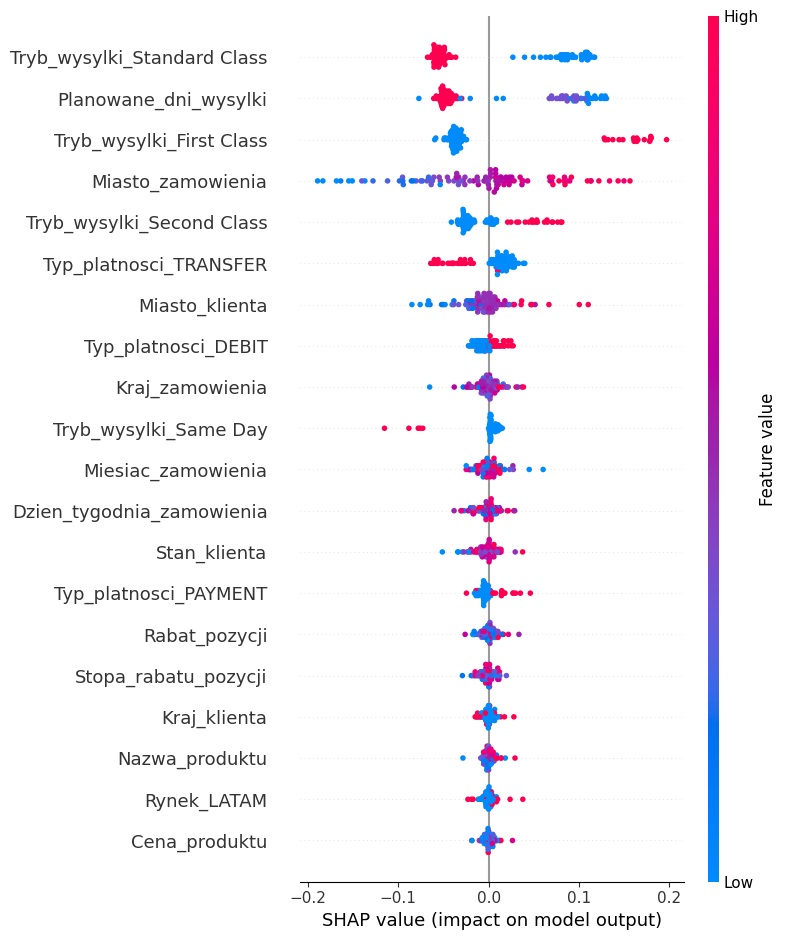

In [7]:
import numpy as np

# Wybieramy SHAP values dla klasy 1 (opóźnienie)
shap_values_klasa1 = shap_values[:, :, 1]

# 1. Summary plot - ogólny wpływ cech na predykcje
shap.summary_plot(shap_values_klasa1, X_sample, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('wykresy/11_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Zamówienie #0
Rzeczywiste ryzyko opóźnienia: 1
Przewidziane prawdopodobieństwo opóźnienia: 0.3500


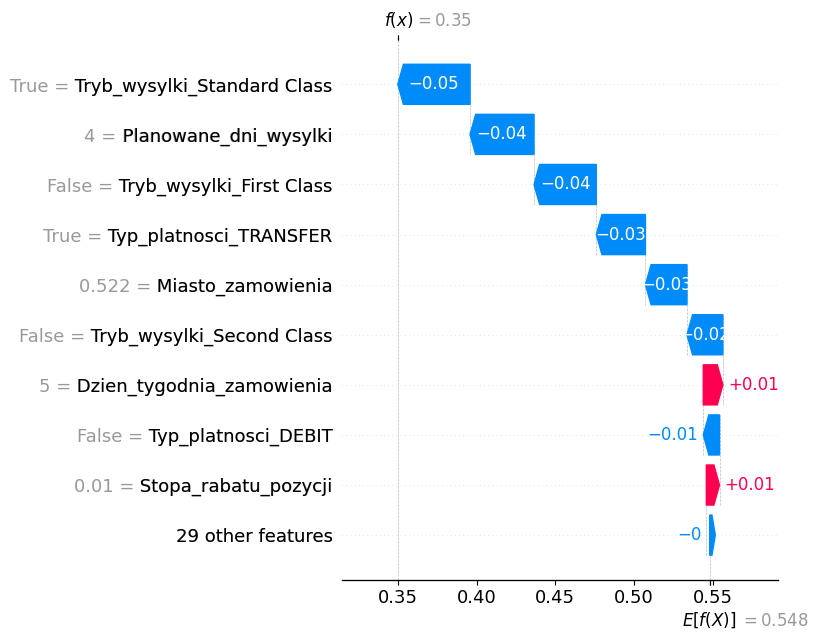

In [8]:
import matplotlib.pyplot as plt

# Wybieramy jedno konkretne zamówienie z próbki (indeks 0 = pierwsze w X_sample)
idx = 0

# Sprawdzamy jaka jest rzeczywista i przewidziana wartość dla tego zamówienia
rzeczywiste = y_test.loc[X_sample.index[idx]]
predykcja_proba = rf_model.predict_proba(X_sample.iloc[[idx]])[0][1]

print(f"Zamówienie #{idx}")
print(f"Rzeczywiste ryzyko opóźnienia: {rzeczywiste}")
print(f"Przewidziane prawdopodobieństwo opóźnienia: {predykcja_proba:.4f}")

# Wartość bazowa (średnie ryzyko w danych) dla klasy 1
base_value = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

shap_explanation = shap.Explanation(
    values=shap_values_klasa1[idx],
    base_values=base_value,
    data=X_sample.iloc[idx],
    feature_names=X_sample.columns.tolist()
)

shap.waterfall_plot(shap_explanation, show=False)
plt.tight_layout()
plt.savefig('wykresy/12_shap_waterfall_przyklad.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import joblib
import json
import os
from datetime import datetime
from sklearn.metrics import roc_auc_score

os.makedirs('models', exist_ok=True)

# Pobieramy finalny model Random Forest z naszego słownika wyników
rf_model_final = wyniki["Random Forest"]["model"]

# Liczymy predykcje i AUC na nowo (żeby mieć aktualne metryki)
y_pred_rf_final = rf_model_final.predict(X_test)
y_proba_rf_final = rf_model_final.predict_proba(X_test)[:, 1]
auc_score_final = roc_auc_score(y_test, y_proba_rf_final)

# Zapisz model
joblib.dump(rf_model_final, 'models/model_random_forest.pkl')

# Zapisz encoder (target encoding, ze smoothing=10)
joblib.dump(encoder, 'models/target_encoder.pkl')

# Zapisz listę kolumn
joblib.dump(list(X_train.columns), 'models/kolumny_modelu.pkl')

# Metadane - rozszerzone o wyniki cross-validation
metadata = {
    "data_treningu": datetime.now().strftime('%Y-%m-%d %H:%M'),
    "model": "RandomForestClassifier",
    "accuracy_test": float(wyniki["Random Forest"]["accuracy"]),
    "accuracy_cv_mean": float(scores_rf.mean()),
    "accuracy_cv_std": float(scores_rf.std()),
    "auc": float(auc_score_final),
    "n_features": X_train.shape[1],
    "cechy_numeryczne": cechy_numeryczne,
    "cechy_onehot": cechy_onehot,
    "cechy_target_encoding": cechy_target_encoding,
    "target_encoding_smoothing": 10
}

with open('models/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Model, encoder i metadane zapisane w folderze models/")
print(f"Accuracy (test): {wyniki['Random Forest']['accuracy']:.4f}")
print(f"Accuracy (CV): {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")
print(f"AUC: {auc_score_final:.4f}")

Model, encoder i metadane zapisane w folderze models/
Accuracy (test): 0.7799
Accuracy (CV): 0.7746 ± 0.0021
AUC: 0.8651
